In [1]:
# YouTube Trending Data Analysis


In [2]:
## Data Loading


In [3]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
import os
os.listdir()

['.config',
 'USvideos.csv',
 'DE_category_id.json',
 'RU_category_id.json',
 'INvideos.csv',
 'MXvideos.csv',
 'MX_category_id.json',
 'KR_category_id.json',
 'CAvideos.csv',
 'GBvideos.csv',
 'KRvideos.csv',
 'RUvideos.csv',
 'FRvideos.csv',
 'GB_category_id.json',
 'FR_category_id.json',
 'JPvideos.csv',
 'IN_category_id.json',
 'JP_category_id.json',
 'CA_category_id.json',
 'US_category_id.json',
 'DEvideos.csv',
 'archive.zip',
 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv('INvideos.csv')

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


In [6]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

In [7]:
## Data Cleaning

In [8]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [9]:
df = df.dropna()

In [10]:
## Exploratory Data Analysis

<Axes: ylabel='channel_title'>

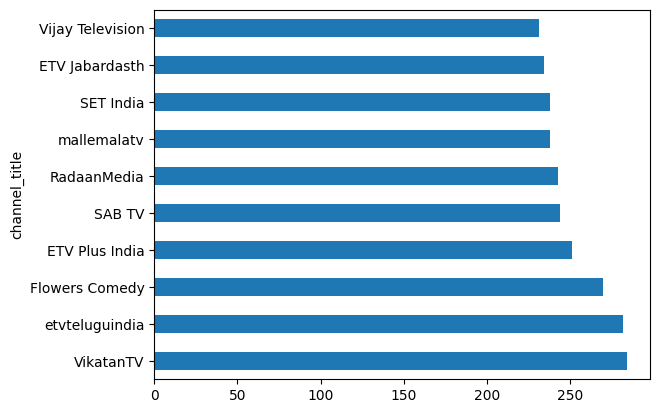

In [11]:
df['channel_title'].value_counts().head(10).plot(kind='barh')

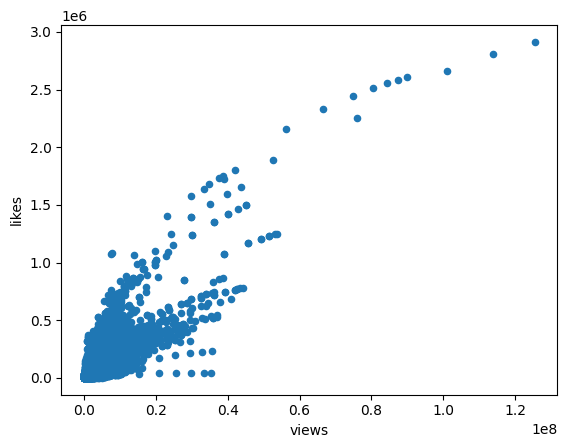

In [12]:
import matplotlib.pyplot as plt

df.plot(kind='scatter', x='views', y='likes')
plt.show()

In [13]:
df['engagement'] = df['likes'] / df['views']

df[['channel_title','engagement']].sort_values(by='engagement', ascending=False).head(10)

,channel_title,engagement
35031,Technical Guruji,0.381917
35169,Technical Guruji,0.381917
16612,Technical Guruji,0.364964
35229,Technical Guruji,0.339015
35360,Technical Guruji,0.339015
6127,Technical Guruji,0.331698
35445,Technical Guruji,0.319896
16850,Technical Guruji,0.295129
6318,Technical Guruji,0.295001
6551,Technical Guruji,0.283022


<Axes: xlabel='publish_time'>

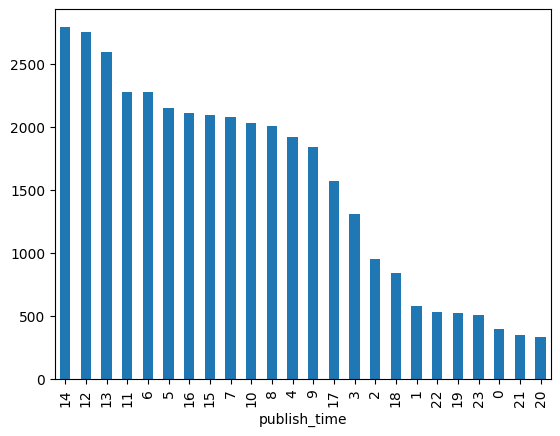

In [14]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

df['publish_time'].dt.hour.value_counts().plot(kind='bar')

In [15]:
## Insights

# Videos with higher views generally tend to receive more likes, showing a strong relationship between popularity and engagement.

# Certain channels appear multiple times in the trending list, indicating consistent content performance and audience reach.

# Engagement (likes/views) varies significantly across videos, meaning not all highly viewed videos are equally liked.

# Some videos with lower views show higher engagement, suggesting niche but highly interactive audiences.

# The timing of video uploads may influence visibility, as certain hours show higher frequency of trending content.